In [17]:
# Import data manipulation libraries
import pandas as pd
import numpy as np 

# Import visualisation libraries
import matplotlib.pyplot as plt 
import seaborn as sns 

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFECV, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

# Import datetime library
from datetime import datetime
import time

In [6]:
# Load the dataset
df = pd.read_csv('adverts.csv')

In [7]:
# Output the first 5 observations
df.head()

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
0,202006039777689,0.0,NaN,Grey,Volvo,XC90,NEW,NaN,73970,SUV,False,Petrol Plug-in Hybrid
1,202007020778260,108230.0,61,Blue,Jaguar,XF,USED,2011.0,7000,Saloon,False,Diesel
2,202007020778474,7800.0,17,Grey,SKODA,Yeti,USED,2017.0,14000,SUV,False,Petrol
3,202007080986776,45000.0,16,Brown,Vauxhall,Mokka,USED,2016.0,7995,Hatchback,False,Diesel
4,202007161321269,64000.0,64,Grey,Land Rover,Range Rover Sport,USED,2015.0,26995,SUV,False,Diesel


In [8]:
# Sample Data
df.sample(5)

,public_reference,mileage,reg_code,standard_colour,standard_make,standard_model,vehicle_condition,year_of_registration,price,body_type,crossover_car_and_van,fuel_type
152619,202009294354916,85954.0,07,Blue,Vauxhall,Corsa,USED,2007.0,1690,Hatchback,False,Petrol
94415,202008122391259,40000.0,17,Grey,Volvo,XC90,USED,2017.0,36950,SUV,False,Petrol Plug-in Hybrid
335196,202008032014028,0.0,NaN,Multicolour,Fiat,500X,NEW,NaN,26820,SUV,False,Petrol
131786,202009203974112,39760.0,14,Yellow,Fiat,500,USED,2014.0,5500,Hatchback,False,Petrol
202193,202010014425152,30441.0,65,Grey,Jeep,Renegade,USED,2015.0,11000,SUV,False,Diesel


In [9]:
# Print out dataframe information 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 402005 entries, 0 to 402004
Data columns (total 12 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   public_reference       402005 non-null  int64  
 1   mileage                401878 non-null  float64
 2   reg_code               370148 non-null  str    
 3   standard_colour        396627 non-null  str    
 4   standard_make          402005 non-null  str    
 5   standard_model         402005 non-null  str    
 6   vehicle_condition      402005 non-null  str    
 7   year_of_registration   368694 non-null  float64
 8   price                  402005 non-null  int64  
 9   body_type              401168 non-null  str    
 10  crossover_car_and_van  402005 non-null  bool   
 11  fuel_type              401404 non-null  str    
dtypes: bool(1), float64(2), int64(2), str(7)
memory usage: 34.1 MB


In [10]:
# Load and sample the dataset
# Load the dataset
df = pd.read_csv('adverts.csv')

# Sample date for quick analysis
df = df.sample(frac=0.2, random_state=99).reset_index(drop=True)

df_aml = df.copy()

In [11]:
# Data Preprocessing
# Reload the sampled data to ensure 'reg_code' column exists
df_aml = df.copy()

# Define a function to derive the registration year from the 'reg_code'
def reg_code_to_year(reg_code):
    try:
        code = int(float(reg_code))
        if 51 <= code <= 99: return 2000 + (code - 50)
        elif 0 < code <= 50: return 2000 + code
        else: return np.nan
    except (ValueError, TypeError):
        return np.nan

# Impute year or registration with derived year using reg_code_to_year function 
df_aml['derived_year'] = df_aml['reg_code'].apply(reg_code_to_year)
df_aml['year_of_registration'] = df_aml['year_of_registration'].fillna(df_aml['derived_year']) if 'year_of_registration' in df_aml.columns else df_aml.get('year_of_registration')
df_aml['vehicle_age'] = datetime.now().year - pd.to_numeric(df_aml.get('year_of_registration', pd.Series()), errors='coerce')

# Log-transform the target variable
df_aml['log_price'] = np.log1p(df_aml['price'])

# Drop irrelevant columns
cols_to_drop = ['public_reference', 'reg_code', 'year_of_registration', 'derived_year']
df_aml.drop(columns=[c for c in cols_to_drop if c in df_aml.columns], inplace=True, errors='ignore')

# Drop missing target rows and duplicates
if df_aml['log_price'].isnull().any():
    df_aml.dropna(subset=['log_price'], inplace=True)
df_aml.drop_duplicates(inplace=True)

# Create missingness indicators
for c in df_aml.columns:
    if df_aml[c].isna().any():
        df_aml[f'{c}_missing'] = df_aml[c].isna().astype(int)

# Define features (X) and target (y)
cols_to_exclude = ['price', 'log_price']
X = df_aml.drop(columns=cols_to_exclude, errors='ignore')
y = df_aml['log_price']

# First split: split the dataset into temp (80%) and test (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

# Second split: split the 80% temp into train and val (75% of temp = 60% overall train, 25% of temp = 20% overall val)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=99)

# Copies to avoid SettingWithCopyWarning
X_train, X_val, X_test = X_train.copy(), X_val.copy(), X_test.copy()

# Identify numeric and categorical columns for imputation and encoding
num_cols_to_impute = X_train.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Imputation (median for numerical and mode for categorical)
imputer_num = SimpleImputer(strategy='median')
X_train[num_cols_to_impute] = imputer_num.fit_transform(X_train[num_cols_to_impute])
X_val[num_cols_to_impute] = imputer_num.transform(X_val[num_cols_to_impute]) 
X_test[num_cols_to_impute] = imputer_num.transform(X_test[num_cols_to_impute])

imputer_cat = SimpleImputer(strategy='most_frequent')
X_train[cat_cols] = imputer_cat.fit_transform(X_train[cat_cols])
X_val[cat_cols] = imputer_cat.transform(X_val[cat_cols]) 
X_test[cat_cols] = imputer_cat.transform(X_test[cat_cols])

# Outlier clipping 
for c in num_cols_to_impute:
    lo, hi = X_train[c].quantile(0.01), X_train[c].quantile(0.99)
    X_train[c] = X_train[c].clip(lower=lo, upper=hi)
    X_val[c] = X_val[c].clip(lower=lo, upper=hi) 
    X_test[c] = X_test[c].clip(lower=lo, upper=hi)

# Rare category handling and frequency encoding
for c in cat_cols:
    freqs = X_train[c].value_counts(normalize=True)
    rares = freqs[freqs < 0.01].index
    
    # Replace rares
    X_train[c] = X_train[c].replace(list(rares), 'Other')
    X_val[c] = X_val[c].replace(list(rares), 'Other')
    X_test[c] = X_test[c].replace(list(rares), 'Other')
    
    # Frequency encoding
    freq_map = X_train[c].value_counts(normalize=True)
    X_train[f'{c}_freq'] = X_train[c].map(freq_map)
    X_val[f'{c}_freq'] = X_val[c].map(freq_map).fillna(0) 
    X_test[f'{c}_freq'] = X_test[c].map(freq_map).fillna(0)

# Separate categorical columns based on cardinality 
low_card_cols, high_card_cols = [], []
for c in cat_cols:
    if X_train[c].nunique() <= 100: low_card_cols.append(c)
    else: high_card_cols.append(c)

# Apply target encoding to high cardinality
for c in high_card_cols:
    target_means = y_train.groupby(X_train[c]).mean()
    X_train[c] = X_train[c].map(target_means).fillna(y_train.mean())
    X_val[c] = X_val[c].map(target_means).fillna(y_train.mean())
    X_test[c] = X_test[c].map(target_means).fillna(y_train.mean())

cat_cols = low_card_cols
num_cols_to_impute.extend(high_card_cols)

# Final feature lists preprocessor
num_colsF = X_train.select_dtypes(include=['number']).columns.tolist()
cat_colsF = X_train.select_dtypes(include=['object', 'category', 'str']).columns.tolist()

# Define preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_colsF),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_colsF)
    ],
    verbose_feature_names_out=False
)

# Fit and transform the training data 
X_train_transformed = preprocessor.fit_transform(X_train)

# Get feature names after transformation
feature_names = preprocessor.get_feature_names_out()

# Create final DataFrames for train, val, and test sets with transformed features
X_train_final = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index) # type: ignore
X_val_final = pd.DataFrame(preprocessor.transform(X_val), columns=feature_names, index=X_val.index) # type: ignore
X_test_final = pd.DataFrame(preprocessor.transform(X_test), columns=feature_names, index=X_test.index) # type: ignore

In [13]:
# Describe output data using shape and info
print("Training set shape:", X_train_final.shape)
print("Validation set shape:", X_val_final.shape)
print("Test set shape:", X_test_final.shape)   
print("\nTraining set info:")
X_train_final.info()
print("\nValidation set info:")
X_val_final.info()
print("\nTest set info:")
X_test_final.info()


Training set shape: (47802, 81)
Validation set shape: (15934, 81)
Test set shape: (15934, 81)

Training set info:
<class 'pandas.DataFrame'>
Index: 47802 entries, 4966 to 25309
Data columns (total 81 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   mileage                          47802 non-null  float64
 1   vehicle_age                      47802 non-null  float64
 2   mileage_missing                  47802 non-null  float64
 3   standard_colour_missing          47802 non-null  float64
 4   body_type_missing                47802 non-null  float64
 5   fuel_type_missing                47802 non-null  float64
 6   vehicle_age_missing              47802 non-null  float64
 7   standard_colour_freq             47802 non-null  float64
 8   standard_make_freq               47802 non-null  float64
 9   standard_model_freq              47802 non-null  float64
 10  vehicle_condition_freq           47802 no

Running RFECV with Linear Regression...
RFECV completed in 11.49 seconds.
Optimal number of features: 73


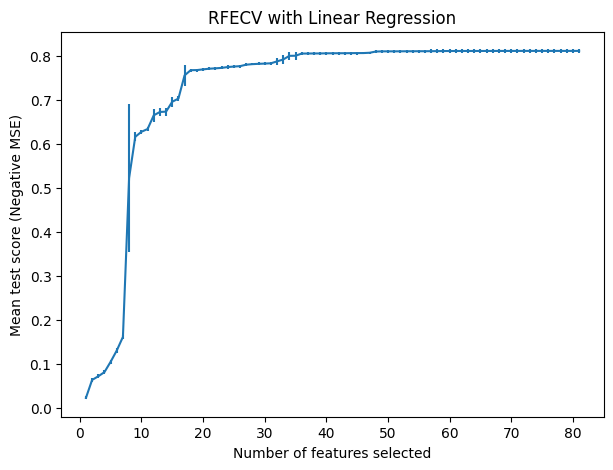


Running Forward SFS with Linear Regression...
SFS completed in 26.06 seconds.

--- Selected Features ---
RFECV selected 73 features.
SFS selected 3 features.

Common features selected by both (3):
['mileage', 'vehicle_age', 'body_type_Hatchback']


In [18]:
# Automated Feature Selection

# Data for feature selection
X_train_fs = X_train_final
y_train_fs = y_train

# Define Linear Regression for feature selection
model = LinearRegression()


# Recursive Feature Elimination (RFECV)
print("Running RFECV with Linear Regression...")
start_time = time.time()

# Use step=1 to evaluate dropping one feature at a time
rfe_selector = RFECV(model, step=1, cv=5, n_jobs=-1)
rfe_selector.fit(X_train_fs, y_train_fs)

print(f"RFECV completed in {time.time() - start_time:.2f} seconds.")
print(f"Optimal number of features: {rfe_selector.n_features_}")

# Plotting using error bars
n_scores = len(rfe_selector.cv_results_["mean_test_score"])
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(
    range(1, n_scores + 1),
    rfe_selector.cv_results_["mean_test_score"],
    yerr=rfe_selector.cv_results_["std_test_score"],
)
ax.set_xlabel("Number of features selected")
ax.set_ylabel("Mean test score (Negative MSE)")
ax.set_title("RFECV with Linear Regression")
plt.show()

# Extract features
rfecv_features = rfe_selector.get_feature_names_out().tolist()



# Sequential Feature Selection (SFS)
print("\nRunning Forward SFS with Linear Regression...")
start_time = time.time()

# Initialise SFS
sfs_forward = SequentialFeatureSelector(
    model, 
    n_features_to_select='auto', 
    direction="forward", 
    tol=0.05, 
    cv=5, 
    n_jobs=-1
).fit(X_train_fs, y_train_fs)

print(f"SFS completed in {time.time() - start_time:.2f} seconds.")

# Extract features
sfs_features = sfs_forward.get_feature_names_out().tolist()


# 5. Review the Outputs
print("\n--- Selected Features ---")
print(f"RFECV selected {len(rfecv_features)} features.")
print(f"SFS selected {len(sfs_features)} features.")

# Find overlapping features
common_features = list(set(rfecv_features).intersection(set(sfs_features)))
print(f"\nCommon features selected by both ({len(common_features)}):")
print(common_features)